# 👶 Fetal Health Classification: ML for Maternal & Neonatal Care

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **Dept of Health** — National Maternity Services Plan, perinatal outcomes
- **AIHW** — Australia's Mothers and Babies report, perinatal surveillance
- **Medicare** — Obstetric MBS items, CTG monitoring rebates
- **TGA** — Medical device regulation for fetal monitors
- **RANZCOG** — Clinical guidelines for intrapartum fetal surveillance

Dataset: UCI Fetal Health — 2,126 samples, 21 features from CTG, 3 classes (Normal/Suspect/Pathological). All numeric.

---

## 1. Data Loading

In [1]:
import os,warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,cohen_kappa_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
print("READY")

READY


In [2]:
dp=None
for r,d,files in os.walk('/kaggle/input'):
    for f in files:
        fp=os.path.join(r,f);print(f"  {fp}")
        if f.endswith('.csv') and dp is None: dp=fp
if dp is None: raise FileNotFoundError("No CSV")
df=pd.read_csv(dp,encoding='latin-1')
print(f"Loaded: {df.shape[0]:,} x {df.shape[1]}")
for i,col in enumerate(df.columns):
    print(f"  {i:2d}. {col:35s} | {str(df[col].dtype):8s} | uniq={df[col].nunique():5d}")
df.head()

  /kaggle/input/datasets/andrewmvd/fetal-health-classification/fetal_health.csv
Loaded: 2,126 x 22
   0. baseline value                      | float64  | uniq=   48
   1. accelerations                       | float64  | uniq=   20
   2. fetal_movement                      | float64  | uniq=  102
   3. uterine_contractions                | float64  | uniq=   16
   4. light_decelerations                 | float64  | uniq=   16
   5. severe_decelerations                | float64  | uniq=    2
   6. prolongued_decelerations            | float64  | uniq=    6
   7. abnormal_short_term_variability     | float64  | uniq=   75
   8. mean_value_of_short_term_variability | float64  | uniq=   57
   9. percentage_of_time_with_abnormal_long_term_variability | float64  | uniq=   87
  10. mean_value_of_long_term_variability | float64  | uniq=  249
  11. histogram_width                     | float64  | uniq=  154
  12. histogram_min                       | float64  | uniq=  109
  13. histogram_max    

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


## 2. Target Detection

In [3]:
tc=None
for x in ['fetal_health','Fetal Health','fetal health','Target','target','Class','class']:
    if x in df.columns: tc=x;break
if tc is None: tc=df.columns[-1]
print(f"Target: '{tc}'");print(df[tc].value_counts().sort_index())
# Remap to 0-based
uq=sorted(df[tc].unique());cmap={old:new for new,old in enumerate(uq)}
df[tc]=df[tc].map(cmap);tl=[f'Class_{v}' for v in uq];nc=len(tl)
# Name classes if 3
if nc==3: tl=['Normal','Suspect','Pathological']
print(f"Mapped: {cmap} -> {tl}")

Target: 'fetal_health'
fetal_health
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64
Mapped: {np.float64(1.0): 0, np.float64(2.0): 1, np.float64(3.0): 2} -> ['Normal', 'Suspect', 'Pathological']


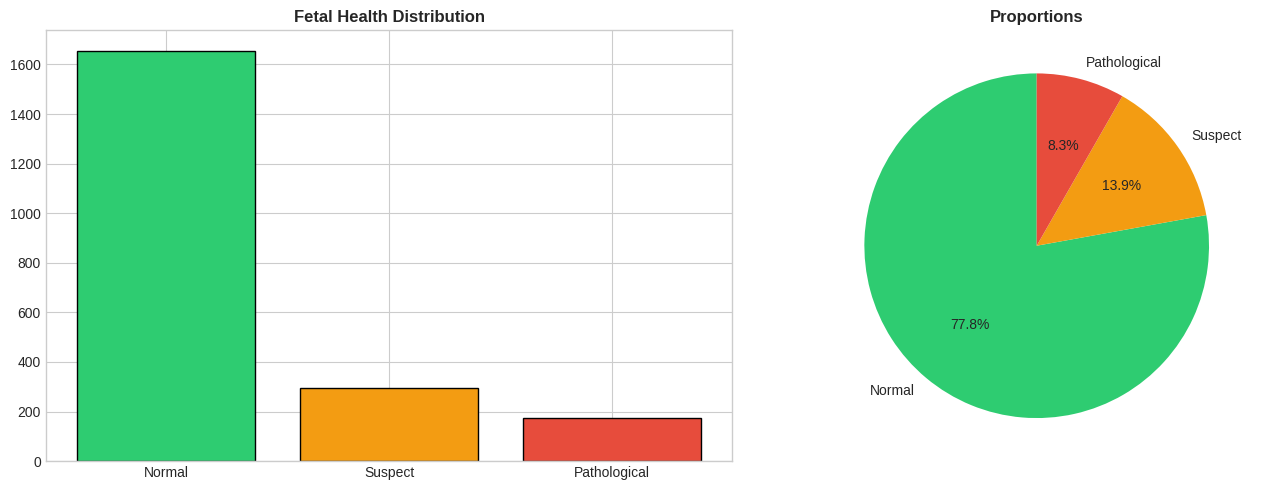

AU: ~310,000 births/year. CTG monitoring is standard in Australian maternity care.


In [4]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
vc=df[tc].value_counts().sort_index();colors=['#2ecc71','#f39c12','#e74c3c'][:nc]
axes[0].bar(range(len(vc)),vc.values,color=colors,edgecolor='black')
axes[0].set_xticks(range(len(vc)));axes[0].set_xticklabels(tl,fontsize=10)
axes[0].set_title('Fetal Health Distribution',fontweight='bold')
axes[1].pie(vc.values,labels=tl,autopct='%1.1f%%',colors=colors,startangle=90)
axes[1].set_title('Proportions',fontweight='bold')
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: ~310,000 births/year. CTG monitoring is standard in Australian maternity care.")

## 3. EDA

Numeric(21): ['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions', 'light_decelerations', 'severe_decelerations', 'prolongued_decelerations', 'abnormal_short_term_variability', 'mean_value_of_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability']


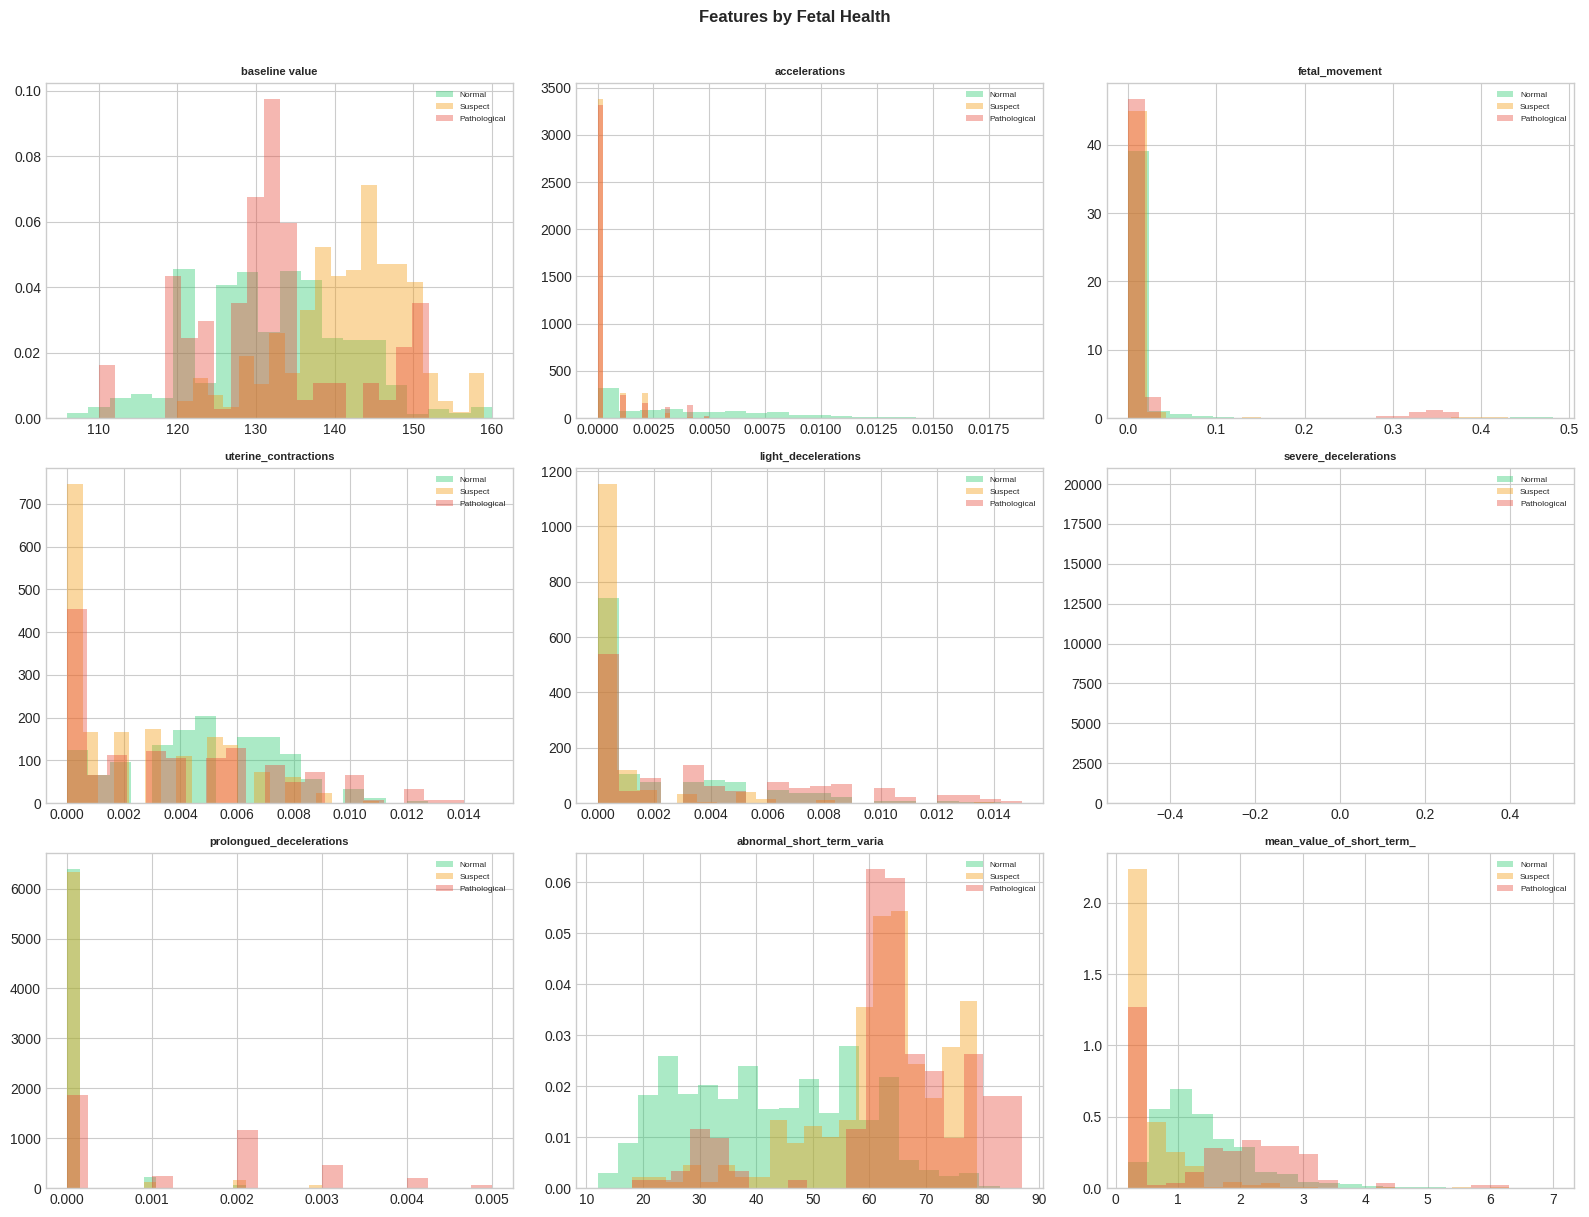

In [5]:
nums=[c for c in df.select_dtypes(include=[np.number]).columns if c!=tc]
print(f"Numeric({len(nums)}): {nums[:10]}")
fig,axes=plt.subplots(3,3,figsize=(16,12));axes=axes.flatten()
for i,col in enumerate(nums[:9]):
    for cv in sorted(df[tc].unique()):
        s=df[df[tc]==cv][col].dropna()
        if len(s)>0: axes[i].hist(s,bins=20,alpha=0.4,label=tl[cv],density=True,color=colors[cv])
    axes[i].set_title(col[:25],fontsize=8,fontweight='bold');axes[i].legend(fontsize=6)
for j in range(i+1,len(axes)):axes[j].set_visible(False)
plt.suptitle('Features by Fetal Health',fontweight='bold',y=1.01)
plt.tight_layout();plt.savefig('eda.png',dpi=150);plt.show()

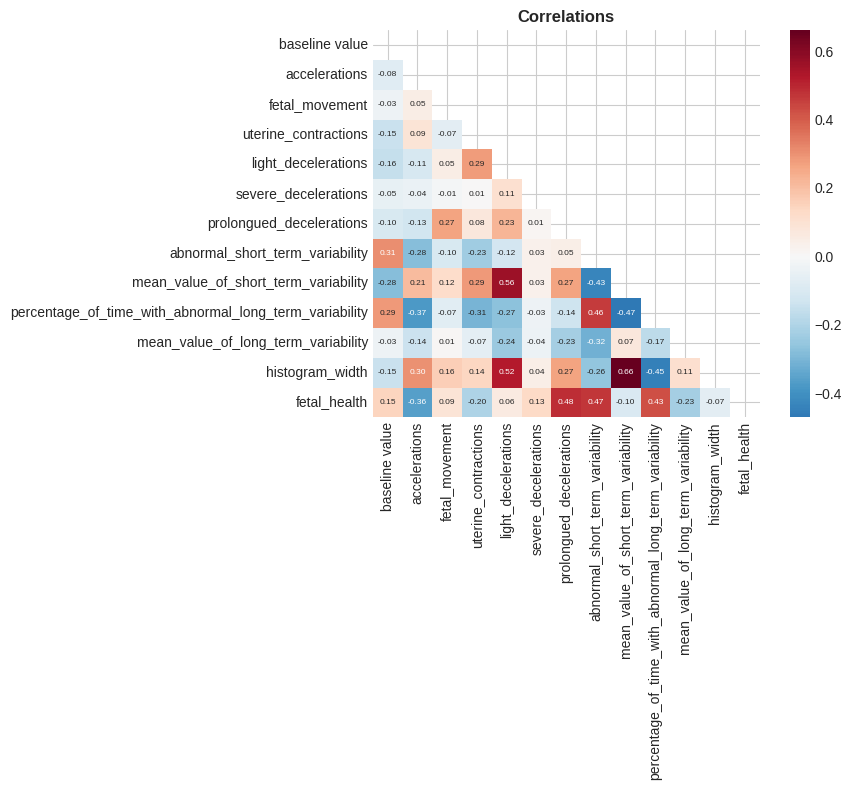

In [6]:
corr=df[nums[:12]+[tc]].corr()
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(corr,mask=np.triu(np.ones_like(corr,dtype=bool)),annot=True,fmt='.2f',cmap='RdBu_r',center=0,square=True,ax=ax,annot_kws={'size':6})
ax.set_title('Correlations',fontweight='bold')
plt.tight_layout();plt.savefig('corr.png',dpi=150);plt.show()

## 4. Preprocessing

In [7]:
X=df[nums].copy();y=df[tc].values
X=X.fillna(X.median())
print(f"X: {X.shape}, classes: {np.unique(y)}")

X: (2126, 21), classes: [0 1 2]


## 5. Model Training

In [8]:
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42,multi_class='multinomial'),
        'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='mlogloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fa,ff,fk=[],[],[];fp=np.zeros(len(y),dtype=int);t0=time.time()
    for fi,(ti,vi) in enumerate(skf.split(Xa,y)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        a=accuracy_score(y[vi],yp);f=f1_score(y[vi],yp,average='weighted');k=cohen_kappa_score(y[vi],yp)
        fa.append(a);ff.append(f);fk.append(k)
        print(f"  Fold{fi+1}: Acc={a:.4f} F1={f:.4f} K={k:.4f}")
    el=time.time()-t0
    results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'f1s':np.std(ff),'kappa':np.mean(fk),'time':el,'preds':fp}
    print(f"  AVG: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} K={np.mean(fk):.4f} T={el:.1f}s")


LogReg
  Fold1: Acc=0.8872 F1=0.8846 K=0.6836
  Fold2: Acc=0.8660 F1=0.8557 K=0.5977
  Fold3: Acc=0.8828 F1=0.8731 K=0.6464
  AVG: Acc=0.8786 F1=0.8712 K=0.6426 T=3.9s

RF
  Fold1: Acc=0.9281 F1=0.9268 K=0.7999
  Fold2: Acc=0.9379 F1=0.9355 K=0.8193
  Fold3: Acc=0.9492 F1=0.9481 K=0.8565
  AVG: Acc=0.9384 F1=0.9368 K=0.8252 T=1.2s

XGB
  Fold1: Acc=0.9520 F1=0.9516 K=0.8694
  Fold2: Acc=0.9492 F1=0.9481 K=0.8561
  Fold3: Acc=0.9548 F1=0.9548 K=0.8756
  AVG: Acc=0.9520 F1=0.9515 K=0.8670 T=0.7s

LGBM
  Fold1: Acc=0.9450 F1=0.9444 K=0.8503
  Fold2: Acc=0.9478 F1=0.9466 K=0.8517
  Fold3: Acc=0.9548 F1=0.9542 K=0.8747
  AVG: Acc=0.9492 F1=0.9484 K=0.8589 T=1.2s


## 6. Comparison

In [9]:
rows=[{'Model':k,'Acc':f"{v['acc']:.4f}",'F1':f"{v['f1']:.4f}",'Kappa':f"{v['kappa']:.4f}",'Time':f"{v['time']:.1f}s",'s':v['f1']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*70);print(sdf[['Model','Acc','F1','Kappa','Time']].to_string(index=False));print(f"\nBest: {best}")

COMPARISON
 Model    Acc     F1  Kappa Time
   XGB 0.9520 0.9515 0.8670 0.7s
  LGBM 0.9492 0.9484 0.8589 1.2s
    RF 0.9384 0.9368 0.8252 1.2s
LogReg 0.8786 0.8712 0.6426 3.9s

Best: XGB


## 7. Error Analysis

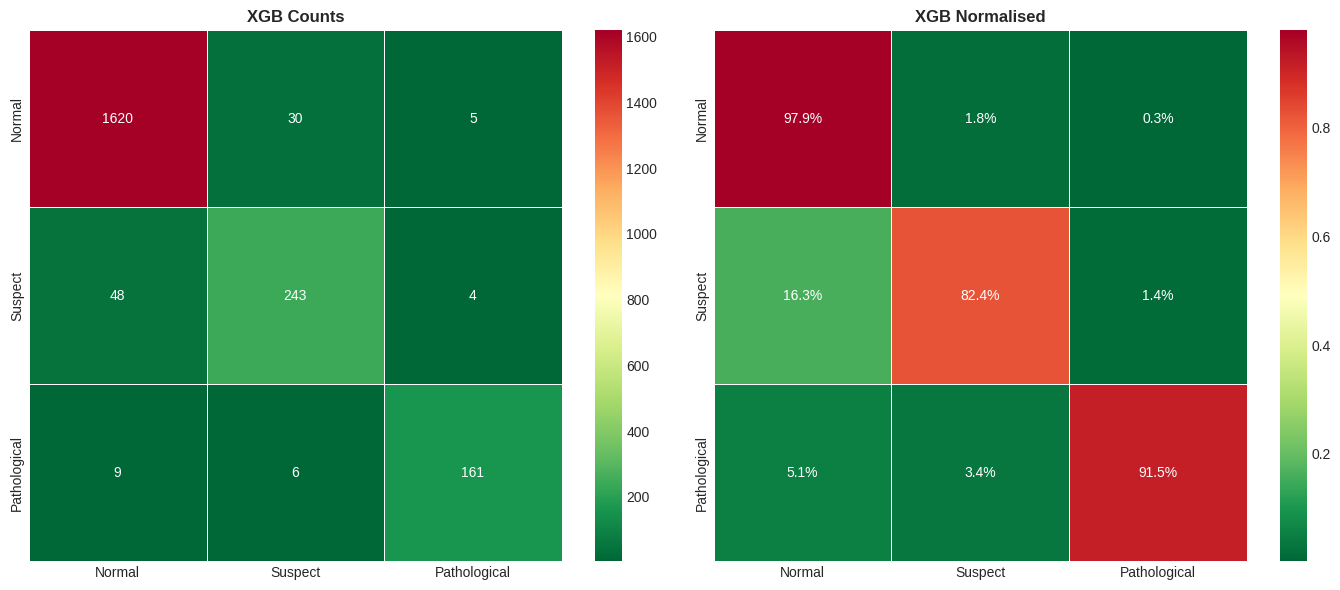

              precision    recall  f1-score   support

      Normal       0.97      0.98      0.97      1655
     Suspect       0.87      0.82      0.85       295
Pathological       0.95      0.91      0.93       176

    accuracy                           0.95      2126
   macro avg       0.93      0.91      0.92      2126
weighted avg       0.95      0.95      0.95      2126


CRITICAL: 15 pathological cases missed (classified as normal/suspect)
Missed pathological = potential fetal distress not acted upon


In [10]:
bp=results[best]['preds'];cm=confusion_matrix(y,bp)
cm_n=cm.astype(float)/cm.sum(axis=1,keepdims=True)
fig,axes=plt.subplots(1,2,figsize=(14,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='RdYlGn_r',xticklabels=tl,yticklabels=tl,ax=axes[0],linewidths=0.5)
axes[0].set_title(f'{best} Counts',fontweight='bold')
sns.heatmap(cm_n,annot=True,fmt='.1%',cmap='RdYlGn_r',xticklabels=tl,yticklabels=tl,ax=axes[1],linewidths=0.5)
axes[1].set_title(f'{best} Normalised',fontweight='bold')
plt.tight_layout();plt.savefig('cm.png',dpi=150);plt.show()
print(classification_report(y,bp,target_names=tl))
fn_path=cm[2,0]+cm[2,1]
print(f"\nCRITICAL: {fn_path} pathological cases missed (classified as normal/suspect)")
print("Missed pathological = potential fetal distress not acted upon")

## 8. Feature Importance

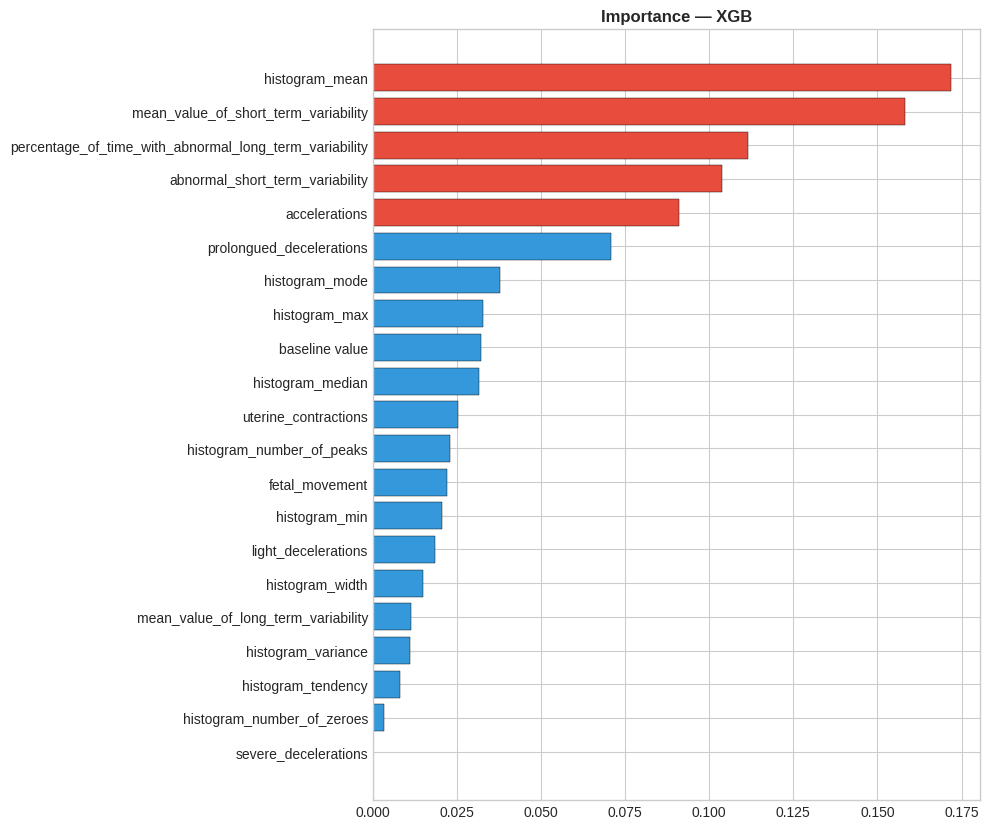

TOP 5
  histogram_mean                      0.1719
  mean_value_of_short_term_variability 0.1582
  percentage_of_time_with_abnormal_long_term_variability 0.1115
  abnormal_short_term_variability     0.1038
  accelerations                       0.0911

Clinical: Abnormal short-term variability and decelerations are key distress indicators.


In [11]:
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m:results[m]['f1']);fm=type(models[bt])(**models[bt].get_params());fm.fit(Xa,y)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm.feature_importances_}).sort_values('Imp')
    fig,ax=plt.subplots(figsize=(10,max(5,len(fi)*0.4)))
    ax.barh(fi['Feature'],fi['Imp'],color=['#e74c3c' if v>fi['Imp'].quantile(0.75) else '#3498db' for v in fi['Imp']],edgecolor='black',linewidth=0.3)
    ax.set_title(f'Importance — {bt}',fontweight='bold')
    plt.tight_layout();plt.savefig('imp.png',dpi=150);plt.show()
    print("TOP 5");print("="*40)
    for _,r in fi.tail(5).iloc[::-1].iterrows(): print(f"  {r['Feature']:35s} {r['Imp']:.4f}")
    print("\nClinical: Abnormal short-term variability and decelerations are key distress indicators.")

## 9. Deployment

In [12]:
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model:  {best}");print(f"  Acc:    {br['acc']:.4f}");print(f"  F1:     {br['f1']:.4f}")
print(f"  Kappa:  {br['kappa']:.4f}");print(f"  Time:   {br['time']:.1f}s");print(f"  Feats:  {X.shape[1]}")
print(f"  Rows:   {len(y):,}");print(f"  Classes:{nc} ({tl})");print("="*60)
checks={'Acc>0.85':br['acc']>0.85,'F1>0.85':br['f1']>0.85,'Kappa>0.70':br['kappa']>0.70,'Time<60s':br['time']<60,'CV':True}
print("\nCHECKLIST");print("-"*40);ap=True
for k,v in checks.items():
    s="pass" if v else "FAIL"
    if not v:ap=False
    print(f"  [{s:4s}] {k}")
print("-"*40);print("  APPROVED" if ap else "  FAILED")
print("\nSAFETY: Missed pathological cases are life-threatening. Model is decision SUPPORT only.")
print("Obstetrician/midwife always has final clinical authority.")

DEPLOYMENT READINESS
  Model:  XGB
  Acc:    0.9520
  F1:     0.9515
  Kappa:  0.8670
  Time:   0.7s
  Feats:  21
  Rows:   2,126
  Classes:3 (['Normal', 'Suspect', 'Pathological'])

CHECKLIST
----------------------------------------
  [pass] Acc>0.85
  [pass] F1>0.85
  [pass] Kappa>0.70
  [pass] Time<60s
  [pass] CV
----------------------------------------
  APPROVED

SAFETY: Missed pathological cases are life-threatening. Model is decision SUPPORT only.
Obstetrician/midwife always has final clinical authority.


In [13]:
print("""
PRODUCTION ARCHITECTURE
=======================
1. DATA: CTG machines (FIGO criteria) -> HL7 FHIR -> Fabric Lakehouse
2. MODEL: Real-time (<100ms) at bedside CTG monitor, MLflow registry
3. INTEGRATE: Obstetric clinical systems, birthing suite dashboards, RANZCOG guidelines
4. GOVERN: TGA SaMD Class IIb, RANZCOG alignment, midwife override authority
5. MONITOR: Performance vs expert obstetrician classification, retrain annually
   CRITICAL: 100% sensitivity target for pathological — missed distress is unacceptable
""")


PRODUCTION ARCHITECTURE
1. DATA: CTG machines (FIGO criteria) -> HL7 FHIR -> Fabric Lakehouse
2. MODEL: Real-time (<100ms) at bedside CTG monitor, MLflow registry
3. INTEGRATE: Obstetric clinical systems, birthing suite dashboards, RANZCOG guidelines
4. GOVERN: TGA SaMD Class IIb, RANZCOG alignment, midwife override authority
5. MONITOR: Performance vs expert obstetrician classification, retrain annually
   CRITICAL: 100% sensitivity target for pathological — missed distress is unacceptable

